In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
conn = sqlite3.connect("../database/air_quality.db")

df = pd.read_sql_query(
    "SELECT * FROM processed_air_quality",
    conn
)

df.head()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day,weekday
0,1,2026-07-17 14:54:48,4,64.12,66.66,508.77,3.62,129.69,4.91,14,17,Friday
1,2,2026-07-17 14:55:44,4,64.12,66.66,508.77,3.62,129.69,4.91,14,17,Friday
2,3,2026-07-17 15:00:02,4,64.12,66.66,508.77,3.62,129.69,4.91,15,17,Friday
3,4,2026-07-17 16:03:49,4,71.83,75.19,522.48,4.51,134.23,5.20,16,17,Friday
4,5,2026-07-17 18:39:46,5,80.25,88.38,734.61,17.07,89.47,7.83,18,17,Friday


In [3]:
X = df[
    [
        "pm2_5",
        "pm10",
        "co",
        "no2",
        "o3",
        "so2",
        "hour",
        "day",
    ]
]

y = df["aqi"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42

)

Linear Regression

In [5]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)


In [6]:
print("Linear Regression")

print("MAE:",mean_absolute_error(y_test,pred_lr))

print("RMSE:",mean_squared_error(y_test,pred_lr)**0.5)

print("R2:",r2_score(y_test,pred_lr))

Linear Regression
MAE: 0.25428886705249837
RMSE: 0.3012797534000093
R2: 0.9093652229989007


Decision Tree

In [7]:
dt = DecisionTreeRegressor(

    random_state=42

)

dt.fit(

    X_train,

    y_train

)

pred_dt = dt.predict(X_test)

In [8]:
print("Decision Tree")

print("MAE:",mean_absolute_error(y_test,pred_dt))

print("RMSE:",mean_squared_error(y_test,pred_dt)**0.5)

print("R2:",r2_score(y_test,pred_dt))

Decision Tree
MAE: 0.0
RMSE: 0.0
R2: 1.0


random forest


In [9]:
rf = RandomForestRegressor(

    n_estimators=100,

    random_state=42

)

rf.fit(

    X_train,

    y_train

)

pred_rf = rf.predict(X_test)

In [10]:
print("Random Forest")

print("MAE:",mean_absolute_error(y_test,pred_rf))

print("RMSE:",mean_squared_error(y_test,pred_rf)**0.5)

print("R2:",r2_score(y_test,pred_rf))

Random Forest
MAE: 0.008103448275862072
RMSE: 0.03471559323694621
R2: 0.9987966162065894


In [11]:
#compare models
results = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Decision Tree",

        "Random Forest"

    ],

    "MAE":[

        mean_absolute_error(y_test,pred_lr),

        mean_absolute_error(y_test,pred_dt),

        mean_absolute_error(y_test,pred_rf)

    ],

    "RMSE":[

        mean_squared_error(y_test,pred_lr)**0.5,

        mean_squared_error(y_test,pred_dt)**0.5,

        mean_squared_error(y_test,pred_rf)**0.5

    ],

    "R2":[

        r2_score(y_test,pred_lr),

        r2_score(y_test,pred_dt),

        r2_score(y_test,pred_rf)

    ]

})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.254289,0.301280,0.909365
1,Decision Tree,0.000000,0.000000,1.000000
2,Random Forest,0.008103,0.034716,0.998797


In [12]:
#save the best model
joblib.dump(

    rf,

    "saved_models/random_forest.pkl"

)

['saved_models/random_forest.pkl']

In [13]:
#load the model
model = joblib.load(

    "saved_models/random_forest.pkl"

)

In [14]:
#predict using the loaded model
sample = X.iloc[[0]]

prediction = model.predict(sample)

print(prediction)

[4.]


In [15]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance.sort_values(

    by="Importance",

    ascending=False

)

,Feature,Importance
0,pm2_5,0.914501
1,pm10,0.072907
2,co,0.005467
4,o3,0.002821
5,so2,0.002083
3,no2,0.001969
6,hour,0.000252
7,day,0.000000


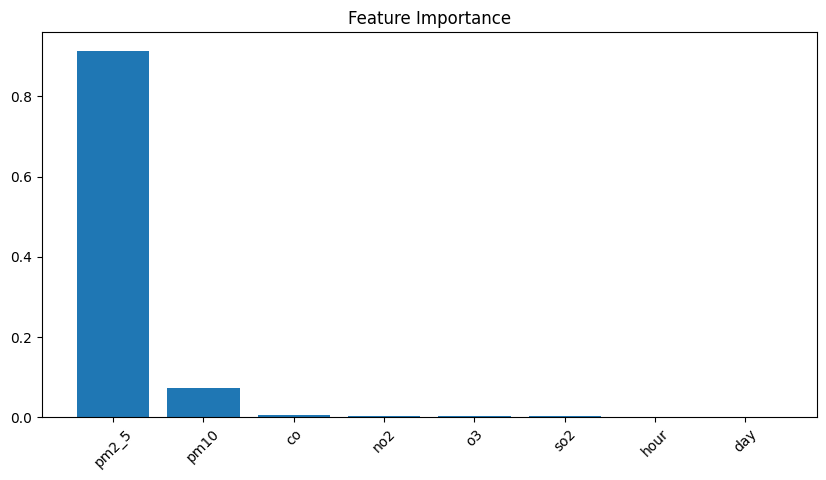

In [16]:
plt.figure(figsize=(10,5))

plt.bar(

    importance["Feature"],

    importance["Importance"]

)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [17]:
results.to_csv(

    "../data/model_results.csv",

    index=False

)